# Housing Price Prediction 🏠📉

[Housing Prices Dataset](https://www.kaggle.com/datasets/yasserh/housing-prices-dataset)

In [2]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge

# src папкасын Python жолына қосу 
sys.path.append(os.path.abspath('../src'))

from metrics import calculate_mape

In [3]:
# Ноутбук орналасқан папканы анықтау
base_path = os.path.dirname(os.getcwd()) 
csv_path = os.path.join(base_path, 'data', 'housing.csv')

data = pd.read_csv(csv_path)
print("Файл сәтті жүктелді!")

Файл сәтті жүктелді!


In [4]:
data.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [5]:
print("Өлшемі: ", data.shape)
print("Бағандар: ", data.columns)


Өлшемі:  (545, 13)
Бағандар:  Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='str')


In [6]:
print("Жалпы талдау:\n", data.describe())

Жалпы талдау:
               price          area    bedrooms   bathrooms     stories  \
count  5.450000e+02    545.000000  545.000000  545.000000  545.000000   
mean   4.766729e+06   5150.541284    2.965138    1.286239    1.805505   
std    1.870440e+06   2170.141023    0.738064    0.502470    0.867492   
min    1.750000e+06   1650.000000    1.000000    1.000000    1.000000   
25%    3.430000e+06   3600.000000    2.000000    1.000000    1.000000   
50%    4.340000e+06   4600.000000    3.000000    1.000000    2.000000   
75%    5.740000e+06   6360.000000    3.000000    2.000000    2.000000   
max    1.330000e+07  16200.000000    6.000000    4.000000    4.000000   

          parking  
count  545.000000  
mean     0.693578  
std      0.861586  
min      0.000000  
25%      0.000000  
50%      0.000000  
75%      1.000000  
max      3.000000  


In [7]:
print("Жалпы ақпарат:\n", data.info())

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB
Жалпы ақпарат:
 None


Барлық сандық емес бағандарды сандық форматқа келтіреміз

In [8]:
# 1. Yes/No бағандарын 1 және 0-ге айналдыру
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
data[binary_cols] = data[binary_cols].replace({'yes': 1, 'no': 0})

# 2. Жиһаздалу деңгейін ретімен көрсету (Ordinal mapping)
data['furnishingstatus'] = data['furnishingstatus'].map({
    'unfurnished': 0, 
    'semi-furnished': 1, 
    'furnished': 2
})

print(data.head())

      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3        1         0        0   
1  12250000  8960         4          4        4        1         0        0   
2  12250000  9960         3          2        2        1         0        1   
3  12215000  7500         4          2        2        1         0        1   
4  11410000  7420         4          1        2        1         1        1   

  hotwaterheating airconditioning  parking prefarea  furnishingstatus  
0               0               1        2        1                 2  
1               0               1        3        0                 2  
2               0               0        2        1                 1  
3               0               1        3        1                 2  
4               0               1        2        0                 2  


<Axes: >

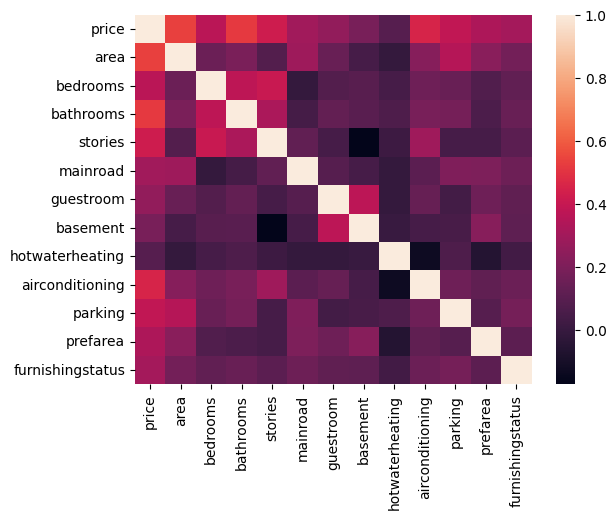

In [9]:
# Корреляция арқылы бағандар арасындағы тәуелділікті көру
sns.heatmap(data.corr())


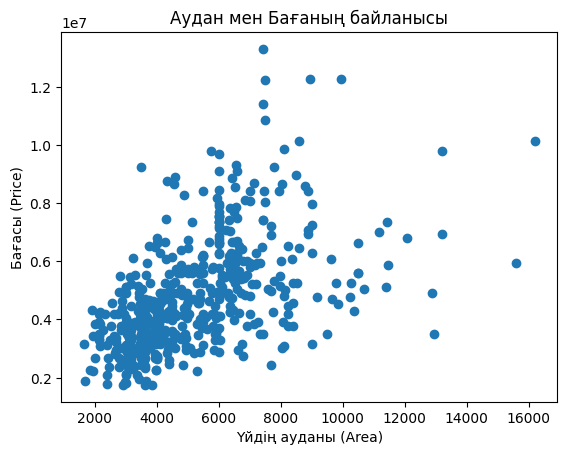

In [10]:
plt.scatter(data['area'], data['price'])
plt.xlabel('Үйдің ауданы (Area)')
plt.ylabel('Бағасы (Price)')
plt.title('Аудан мен Бағаның байланысы')
plt.show()

<Axes: ylabel='area'>

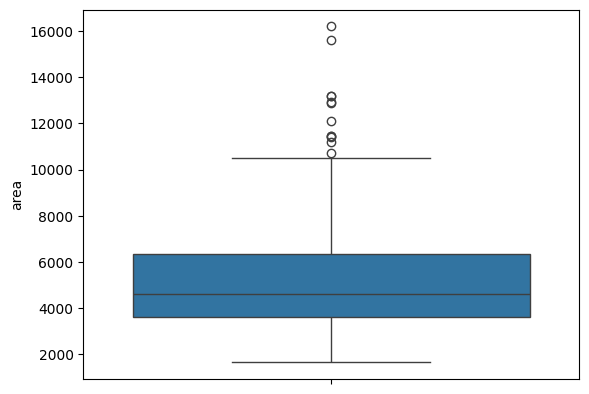

In [11]:
# area бағаны бойынша шашыраңқылық
sns.boxplot(data['area'])

In [12]:
# 1. Квартильдерді есептеу (25% және 75%)
Q1 = data['area'].quantile(0.25)
Q3 = data['area'].quantile(0.75)
IQR = Q3 - Q1

# 2. Шектерді анықтау
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 3. Осы шектен шықпайтын деректерді ғана қалдыру
# Шектен тыс ақпарат көп емес, оларды алмайак қойсақ болады
data = data[(data['area'] >= lower_bound) & (data['area'] <= upper_bound)]

print(f"Тазалаудан кейінгі деректер саны: {len(data)}")

Тазалаудан кейінгі деректер саны: 533


In [13]:
data.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,2
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,2
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,2
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,2


## Linear Regression Model - Масштабтаусыз

In [14]:
# Белгілер (features) пен таргетке (target) бөлу
X = data.drop('price', axis=1)
y = data.price


# train, test бөліктеріне бөлу
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

print("Оқыту және тест ақпараттары дайын!")


Оқыту және тест ақпараттары дайын!


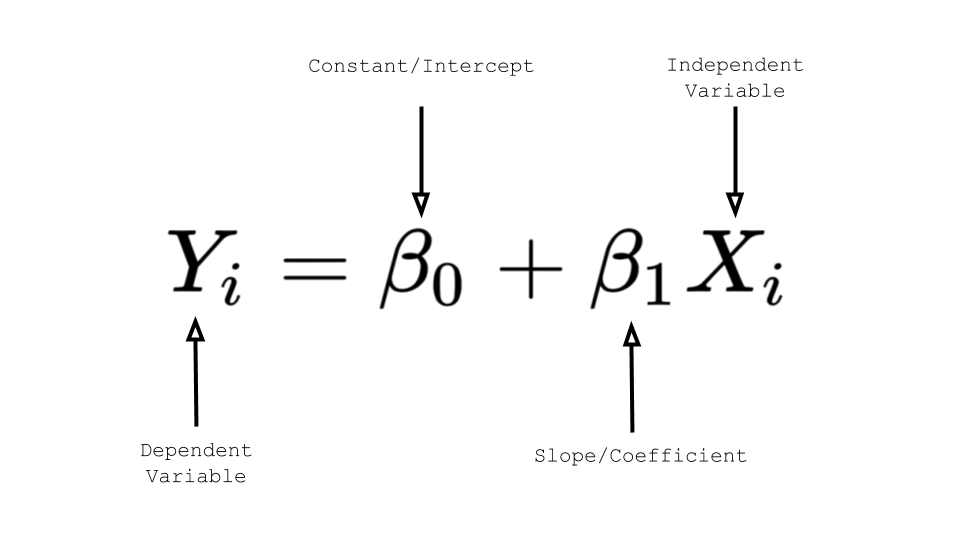

In [15]:
# Сызықтық регрессия моделін құру
lin_model = LinearRegression()

# Модельді оқыту
lin_model.fit(X_train, y_train)

print("Coefficient: ", *lin_model.coef_, sep='\n')
print("Intercept: ", lin_model.intercept_)

Coefficient: 
257.88443592271494
159692.4347125888
1013664.1459431683
419802.7179454006
421936.13722084364
255924.65851377143
355677.9777239258
764173.9249481505
798295.9053856249
281211.0768806997
593598.4590164489
206355.3422724287
Intercept:  -416775.95731407404


In [16]:
# Тест ақпараттарына болжам жасаймыз
y_pred = lin_model.predict(X_test)

# Орташа квадраттық ауытқуды анықтау
mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)
print("RMSE:", mse ** 0.5)


# Орташа абсолюттік ауытқу
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MSE: 1024895443667.8387
RMSE: 1012371.1985570504
MAE: 728109.0739752197


Болжанған баға: 4,646,960.22
Нақты баға: 4,543,000.00
Айырмашылық: 103,960.22


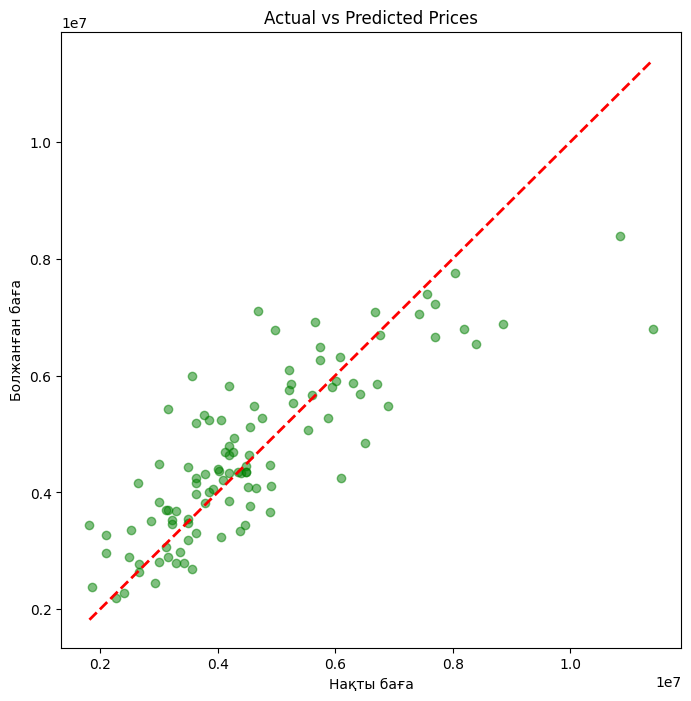

In [17]:
# Тест жиынтығынан 10-шы үйді алайық (кез келген индекс болады)
house_index = 10 
sample_house = X_test.iloc[[house_index]]

# Болжам жасау
predicted_price = lin_model.predict(sample_house)

# Нақты бағасын алу (салыстыру үшін)
actual_price = y_test.iloc[house_index]

print(f"Болжанған баға: {predicted_price[0]:,.2f}")
print(f"Нақты баға: {actual_price:,.2f}")
print(f"Айырмашылық: {abs(predicted_price[0] - actual_price):,.2f}")


# Модельді визуализациялау
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.5, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Идеал түзу
plt.xlabel('Нақты баға')
plt.ylabel('Болжанған баға')
plt.title('Actual vs Predicted Prices')
plt.show()

In [18]:
# Пайыздық қателікті есептеу
# src/metrics.py -> calculate_mape()
mape_result = calculate_mape(y_test, y_pred)

print(f"Модельдің орташа қателігі: {mape_result:.2f}%")

Модельдің орташа қателігі: 16.98%


## Linear Regression Model - Ridge Model

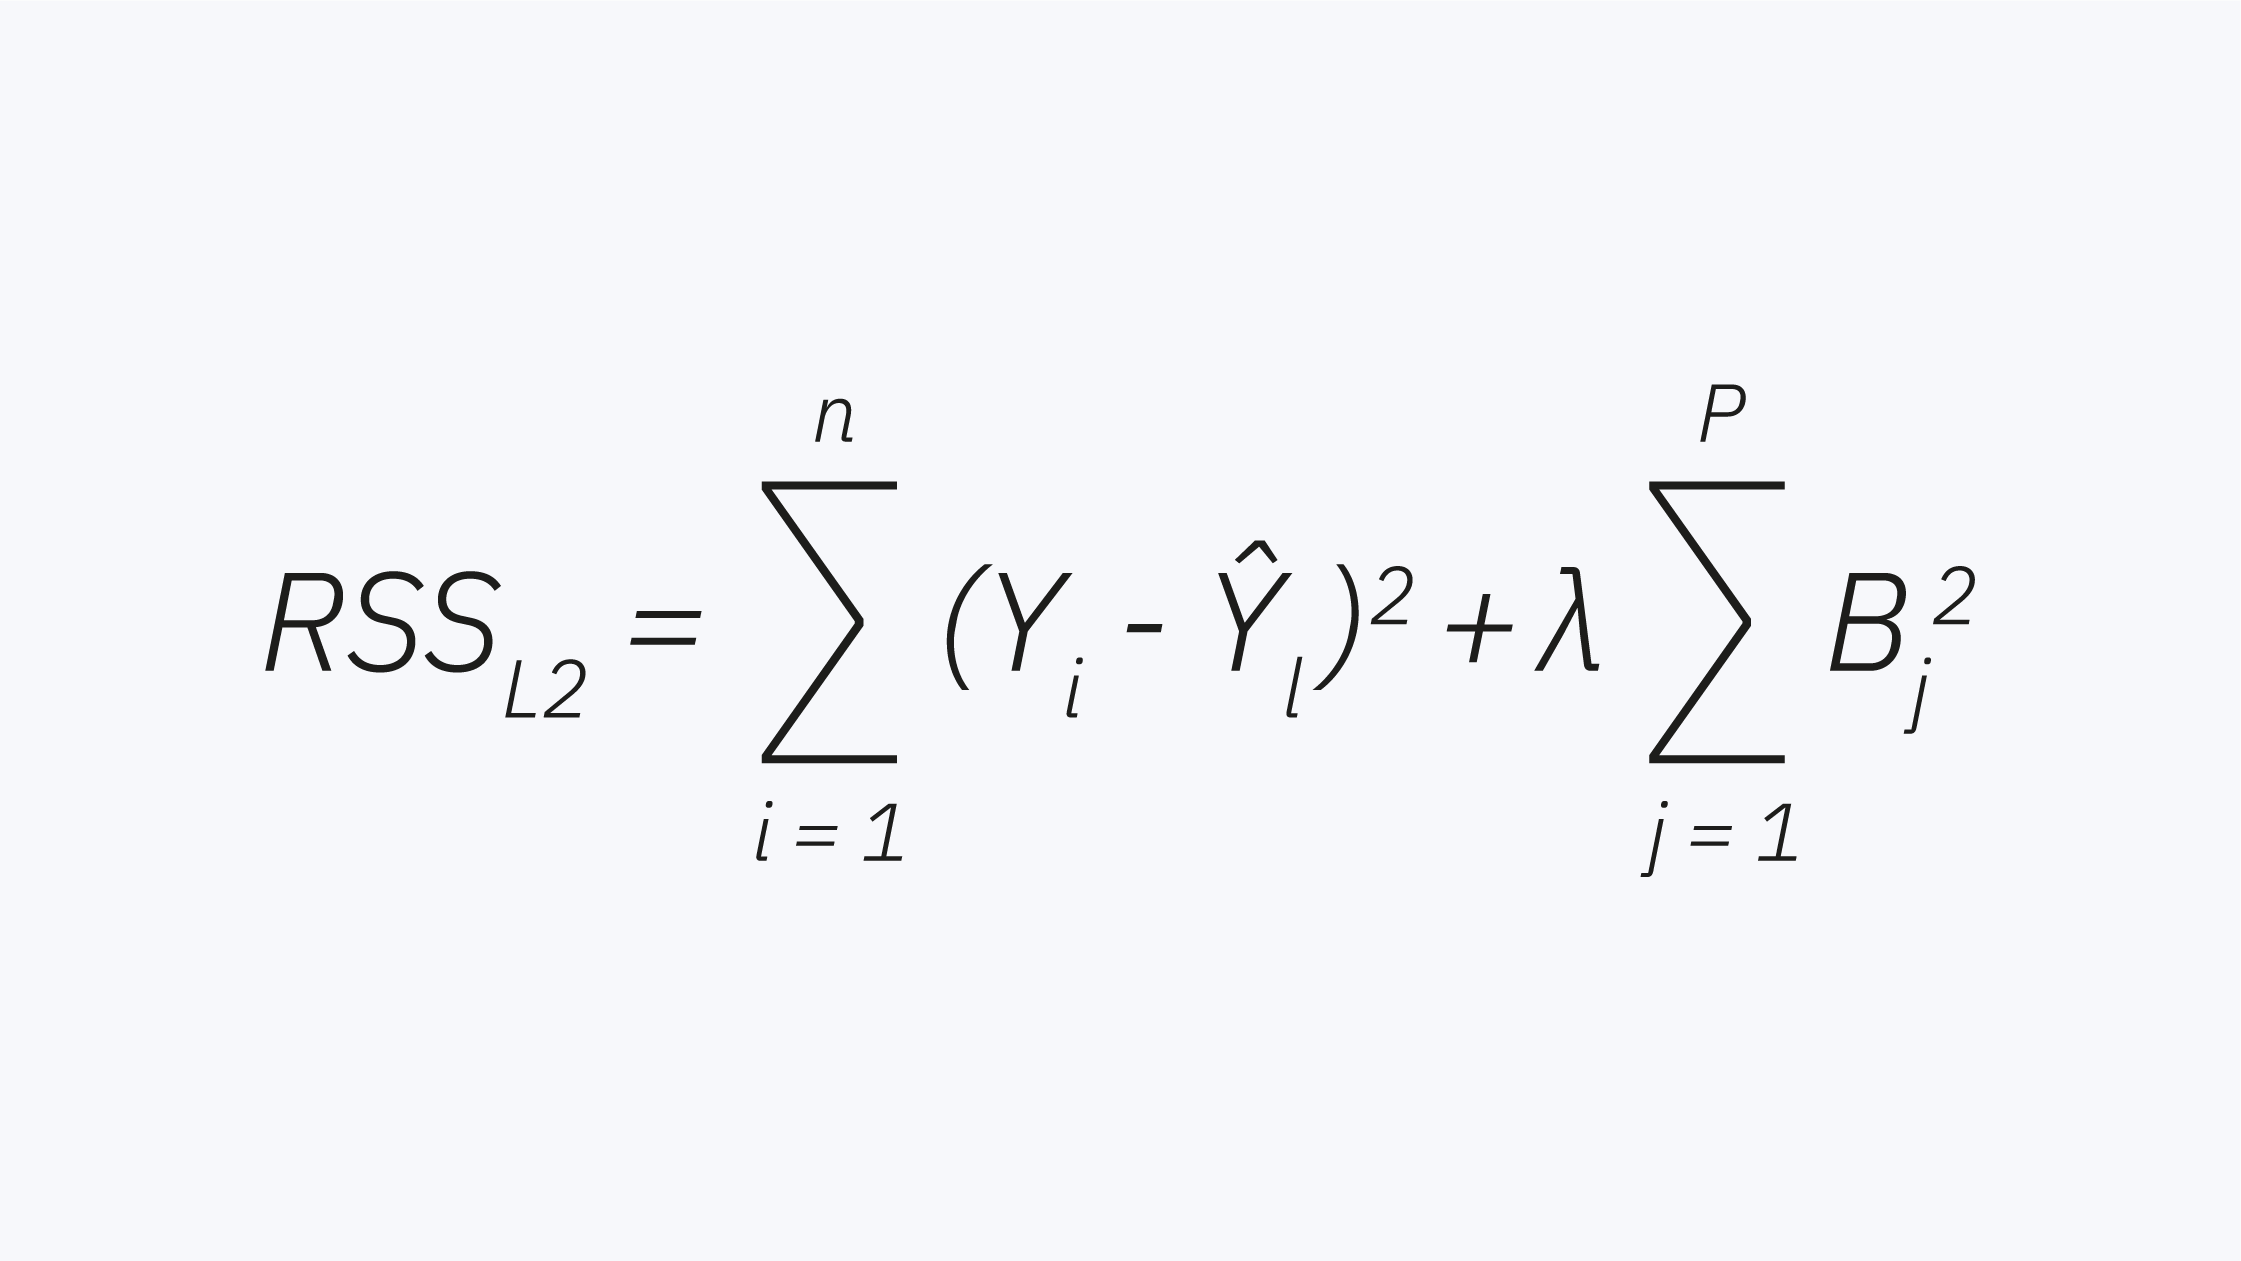

In [26]:
# Ridge модель құру және alpha бойынша салыстыру
alphas = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]
mapes = []

# StandardScaler объект құрамыз
scaler = StandardScaler()

# Масштабтаймыз
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# alpha бойынша бірнеше модельді аламыз
for alpha in alphas:

    # Ridge модель
    ridge = Ridge(alpha=alpha)

    # модельді оқытамыз
    ridge.fit(X_train_scaled, y_train)

    # Болжам жасаймыз
    y_pred_scaled = ridge.predict(X_test_scaled)

    # Орташа проценттік қате аламыз
    mape_result = calculate_mape(y_true=y_test, y_pred=y_pred_scaled)

    # Жалпы тізімге қосамыз
    mapes.append(mape_result)

print("Сәтті аяқталды!")
    

Сәтті аяқталды!


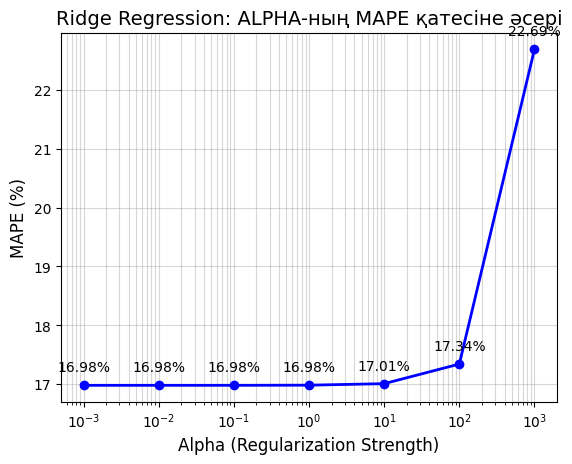

In [27]:
# Рисуем линию с точками
plt.plot(alphas, mapes, marker='o', linestyle='-', color='b', linewidth=2)

# Делаем ось X логарифмической (чтобы 0.01 и 100 были видны одинаково хорошо)
plt.xscale('log')

# Добавляем названия осей и заголовок
plt.xlabel('Alpha (Regularization Strength)', fontsize=12)
plt.ylabel('MAPE (%)', fontsize=12)
plt.title('Ridge Regression: ALPHA-ның MAPE қатесіне әсері', fontsize=14)

# Добавляем сетку для удобства
plt.grid(True, which="both", ls="-", alpha=0.5)

# Можно добавить подписи значений MAPE над точками
for i, mape in enumerate(mapes):
    plt.annotate(f"{mape:.2f}%", (alphas[i], mapes[i]), textcoords="offset points", xytext=(0,10), ha='center')

plt.show()

Гиперпараметрдің оңтайлы мәні Alpha = 0.01 (немесе одан аз) болып табылады, өйткені реттелу күші одан әрі артқан сайын сынақ деректеріндегі модельдің дәлдігі төмендейді. Бұл бастапқы үлгіде таразыны агрессивті түрде басуды қажет ететін артық күрделілік жоқ екенін дәлелдейді.

## Жобаның қысқаша түйіндемесі:
 - Модель: **Сызықтық регрессия (Linear Regression)** және **Ridge-регуляризациясы** қолданылды.
 - Деректер (Data): 12 түрлі көрсеткіш (features) негізінде баспана бағасын болжау жүзеге асырылды.
 - Нәтиже (MAPE): Ең төменгі қателік көрсеткіші 16.98% болды. Бұл баспана нарығы үшін жақсы көрсеткіш (Good accuracy).
 - Ridge-регрессияның рөлі: Тәжірибе барысында $\alpha$ (Alpha) параметрін арттыру қателіктің өсуіне әкелді (16.98%-дан 22.69%-ға дейін). Бұл бастапқы қарапайым модельдің қайта оқытылмағанын (overfitting жоқ екенін) дәлелдейді. 
 - Техникалық деңгей: Жобада StandardScaler арқылы масштабтау, файлдарды src және notebooks деп бөлу, сондай-ақ matplotlib арқылы логарифмдік шкалада график құру сияқты кәсіби тәсілдер қолданылды.